<center><img src="./graphics/redpopcorn.jpg"></center>

**Netflix**! What started in 1997 as a DVD rental service has since exploded into one of the largest entertainment and media companies.

Given the large number of movies and series available on the platform, it is a perfect opportunity to flex our exploratory data analysis skills and dive into the entertainment industry.

Let's say that we work for a production company that specializes in nostalgic styles. We want to do some research on movies released in the 1990's. We'll take a quick look into Netflix data and perform some EDA (exploratory data analysis) to better understand this awesome movie decade!

The data we have been supplied with is the file `netflix_data.csv`, along with the following table detailing the column names and descriptions.

## The data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [1]:
# importing pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# read in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("./data/netflix_data.csv")

In [2]:
netflix_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       4812 non-null   str  
 1   type          4812 non-null   str  
 2   title         4812 non-null   str  
 3   director      4812 non-null   str  
 4   cast          4812 non-null   str  
 5   country       4812 non-null   str  
 6   date_added    4812 non-null   str  
 7   release_year  4812 non-null   int64
 8   duration      4812 non-null   int64
 9   description   4812 non-null   str  
 10  genre         4812 non-null   str  
dtypes: int64(2), str(9)
memory usage: 1.9 MB


In [3]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
1,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
2,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
3,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas
4,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,"July 1, 2017",2016,1,A genetics professor experiments with a treatm...,International TV


## How do the duration of these movies distribute?

<Axes: xlabel='duration', ylabel='Count'>

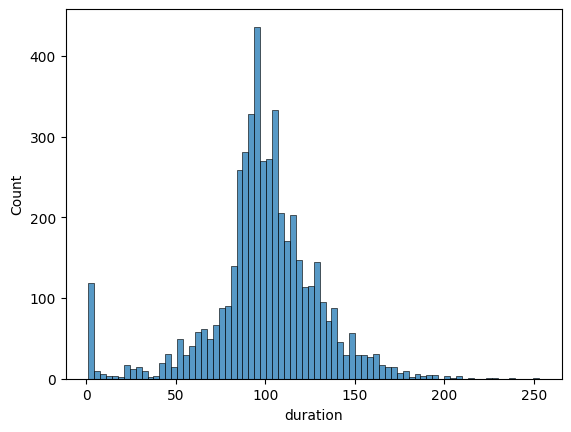

In [4]:
sns.histplot(netflix_df['duration'])

## What is the most frequent duration?

The histogram suggests the most typical duration is somewhere between 75 and 125.

In [5]:
duration_counts_all = netflix_df['duration'].value_counts().sort_index()
duration_counts_top = duration_counts_all.loc[(duration_counts_all >=75) & (duration_counts_all < 125)]
print(duration_counts_top.sort_values(ascending=False).iloc[:5])

duration
93    121
94    119
90    114
95    111
97    107
Name: count, dtype: int64


In [6]:
most_freq_duration = netflix_df['duration'].mode()
print(f"Most frequent duration: {most_freq_duration.iloc[0]} minutes")

Most frequent duration: 93 minutes


## Zeroing in on the '90s

How many action movies came out under 90 minutes?

In [7]:
movies_1990s = netflix_df.loc[(netflix_df['release_year'] >= 1990) & \
                              (netflix_df['release_year'] <= 1999)]
movies_1990s_action = movies_1990s.loc[(movies_1990s['type'] == 'Movie') & \
                                       (movies_1990s['genre'] == 'Action')]
short_movie_count = movies_1990s_action.loc[movies_1990s_action['duration'] < 90].shape[0]
short_movie_count

7

## How many releases were there by genre in the 90's?

There were 11 genres listed in the 90's

There were 31 genres in the overall data

The top 3 genres of the 90's were: ['Action', 'Dramas', 'Comedies']


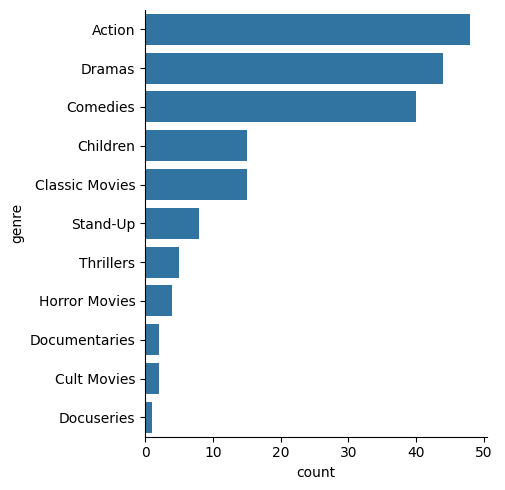

In [8]:
releases_by_genre_90s = movies_1990s['genre'].value_counts()
print(f"There were {releases_by_genre_90s.shape[0]} genres listed in the 90's\n")
print(f"There were {netflix_df['genre'].value_counts().shape[0]} genres in the overall data\n")
print(f"The top 3 genres of the 90's were: {releases_by_genre_90s.index[0:3].tolist()}")
# releases_by_genre_90s

# visualize releases by genre
genre_order = releases_by_genre_90s.index.tolist()
sns.catplot(y='genre', data=movies_1990s, kind='count', order=genre_order)
plt.show()

## Duration difference between genres

Is there a significant difference in duration between the **Action**, **Dramas** and **Comedies** genres since 1990?

In [9]:
movies_since_1990 = netflix_df.loc[(netflix_df['release_year'] >= 1990)]
print(f"Count of movies release from 1990: {movies_since_1990.shape[0]}")
print(f"Latest year movie release:         {movies_since_1990['release_year'].max()}")
action_durations = movies_since_1990.loc[movies_since_1990['genre'] == 'Action', 'duration']
drama_durations = movies_since_1990.loc[movies_since_1990['genre'] == 'Dramas', 'duration']
comedy_durations = movies_since_1990.loc[movies_since_1990['genre'] == 'Comedies', 'duration']
print(f"Average duration of Action movies: {round(action_durations.mean(), 2)} minutes")
print(f"Average duration of Drama movies:  {round(drama_durations.mean(), 2)} minutes")
print(f"Average duration of Comedy movies: {round(comedy_durations.mean(), 2)} minutes")

Count of movies release from 1990: 4621
Latest year movie release:         2021
Average duration of Action movies: 112.24 minutes
Average duration of Drama movies:  111.66 minutes
Average duration of Comedy movies: 106.62 minutes


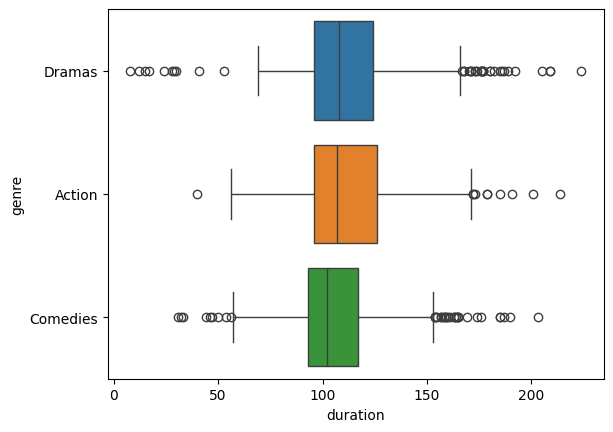

In [10]:
# start with a visual
top_3_90s_genres = movies_since_1990.loc[movies_since_1990['genre'].isin(['Action', 'Dramas', 'Comedies']), :]
sns.boxplot(x='duration', y='genre', data=top_3_90s_genres, hue='genre')

plt.show()

In [11]:
import scipy.stats as stats

f_stat, p_val = stats.f_oneway(action_durations, drama_durations, comedy_durations)
print(f"F-statistic: {f_stat:.4f}")  # 18.4235
print(f"P-value: {p_val:.4f}")       # < 0.0001

F-statistic: 18.4235
P-value: 0.0000


## There is a difference between these 3 genres

The 1-way ANOVA between these indicate that there is a signficant differences between durations in at least one of the three possible pairs. However, we don't know which pair or pairs have significant differences yet. We'll need to do a little more work to determine which ***pairs of genres*** are different.

In [12]:
import pingouin as ping

ping.pairwise_tests(data=top_3_90s_genres, dv="duration", between="genre", padjust="bonf")

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,BF10,hedges
0,genre,Action,Comedies,False,True,5.050326,1262.903786,two-sided,5.057751e-07,1.517325e-06,bonf,1.588e+04,0.260878
1,genre,Action,Dramas,False,True,0.522621,1291.701489,two-sided,6.013278e-01,1.000000e+00,bonf,0.062,0.025051
2,genre,Comedies,Dramas,False,True,-5.519422,2262.928218,two-sided,3.789871e-08,1.136961e-07,bonf,1.603e+05,-0.227901


## Further test confirm was we see visually

The boxplots suggest that the difference between ***Action*** and ***Dramas*** may not be significant and the Bonferroni-adjusted pairwise tests results in the previous cell confirms this. Similarly, the difference in duration between ***Comedies*** and ***Action*** is signficant as is the difference between ***Comedies*** and ***Dramas***.